In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token="your token",
    overwrite=True
)

In [4]:
service = QiskitRuntimeService(channel="ibm_cloud")

qiskit_runtime_service.__init__:WARNING:2026-07-09 08:51:05,653: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

print("Connected successfully!")

qiskit_runtime_service.__init__:WARNING:2026-07-11 21:56:38,221: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Connected successfully!


In [3]:
for backend in service.backends():
    print(backend.name)

qiskit_runtime_service.backends:WARNING:2026-07-11 21:56:39,272: Loading instance: open-instance, plan: open


ibm_fez
ibm_marrakesh
ibm_kingston


In [4]:
backend = service.backend("ibm_kingston")

qiskit_runtime_service.backends:WARNING:2026-07-11 21:56:48,012: Using instance: open-instance, plan: open


In [5]:
# ============================================================
# HISTOGRAM FOR XOR-BASED HAMMING NETWORK
# ============================================================

from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    ClassicalRegister,
    transpile
)


from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

# ============================================================
# HELPER FUNCTION
# ============================================================

def initialize_bits(qc, reg, bitstring):

    for i, bit in enumerate(reversed(bitstring)):

        if bit == '1':

            qc.x(reg[i])

# ============================================================
# REGISTERS
# ============================================================

D = QuantumRegister(3, 'D')

N1 = QuantumRegister(3, 'N1')

N2 = QuantumRegister(3, 'N2')

X1 = QuantumRegister(3, 'X1')

X2 = QuantumRegister(3, 'X2')

C1 = ClassicalRegister(3, 'C1')

C2 = ClassicalRegister(3, 'C2')

# ============================================================
# CIRCUIT
# ============================================================

qc = QuantumCircuit(
    D, N1, N2,
    X1, X2,
    C1, C2
)

# ============================================================
# INPUTS
# Destination = 101
# Neighbor1   = 111
# Neighbor2   = 000
# ============================================================

initialize_bits(qc, D,  "101")

initialize_bits(qc, N1, "111")

initialize_bits(qc, N2, "000")

qc.barrier(label='INPUT')

# ============================================================
# XOR NETWORK
# X1 = D XOR N1
# X2 = D XOR N2
# ============================================================

for i in range(3):

    qc.cx(D[i], X1[i])

    qc.cx(N1[i], X1[i])

    qc.cx(D[i], X2[i])

    qc.cx(N2[i], X2[i])

qc.barrier(label='XOR OUTPUT')

# ============================================================
# MEASUREMENT
# ============================================================

qc.measure(X1, C1)

qc.measure(X2, C2)

# ============================================================
# DISPLAY CIRCUIT
# ============================================================

fig = qc.draw(
    output='mpl',
    fold=120,
    idle_wires=False,
    style='iqp'
)

fig.savefig(
    "xor_hamming_network.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
# ============================================================
# TRANSPILE FOR IBM KINGSTON
# ============================================================

transpiled_qc = transpile(
    qc,
    backend=backend,
    optimization_level=3
)

print("\n========== IBM HARDWARE METRICS ==========\n")

print("Backend       :", backend.name)
print("Circuit Depth :", transpiled_qc.depth())
print("Circuit Width :", transpiled_qc.width())
print("Total Qubits  :", transpiled_qc.num_qubits)
print("Circuit Size  :", transpiled_qc.size())

print("\nGate Counts:\n")
print(transpiled_qc.count_ops())

# ============================================================
# DISPLAY TRANSPILED CIRCUIT
# ============================================================

transpiled_fig = transpiled_qc.draw(
    output='mpl',
    fold=120,
    idle_wires=False,
    style='iqp'
)

transpiled_fig.savefig(
    "xor_hamming_network_transpiled.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# EXECUTE ON IBM KINGSTON
# ============================================================

from qiskit_ibm_runtime import SamplerV2

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [transpiled_qc],
    shots=1024
)

print("\n====================================================")
print("IBM RUNTIME JOB SUBMITTED")
print("====================================================")

print("Job ID :", job.job_id())

print("\nWaiting for execution...\n")

result = job.result()

print("Execution Complete.")

# ============================================================
# EXTRACT COUNTS
# ============================================================

pub = result[0]

print("\nReturned Data Structure:\n")
print(pub.data)

# Since C1 and C2 are returned separately by IBM Runtime
x1_counts = pub.data.C1.get_counts()
x2_counts = pub.data.C2.get_counts()

print("\n========== X1 RAW COUNTS ==========\n")
print(x1_counts)

print("\n========== X2 RAW COUNTS ==========\n")
print(x2_counts)

# ============================================================
# SUCCESS PROBABILITY
# ============================================================

expected_x1 = "010"
expected_x2 = "101"

x1_success = x1_counts.get(expected_x1, 0)
x2_success = x2_counts.get(expected_x2, 0)

shots = 1024

print("\n========== SUCCESS PROBABILITY ==========\n")

print(f"X1 Success : {x1_success}/{shots} = {100*x1_success/shots:.2f}%")
print(f"X2 Success : {x2_success}/{shots} = {100*x2_success/shots:.2f}%")

# ============================================================
# DISPLAY X1 HISTOGRAM
# ============================================================

print("\n========== X1 HISTOGRAM ==========\n")

x1_fig = plot_histogram(
    x1_counts,
    figsize=(7,5),
    bar_labels=True,
    title="Histogram of XOR Output X1"
)

x1_fig.savefig(
    "x1_histogram_ibm.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# DISPLAY X2 HISTOGRAM
# ============================================================

print("\n========== X2 HISTOGRAM ==========\n")

x2_fig = plot_histogram(
    x2_counts,
    figsize=(7,5),
    bar_labels=True,
    title="Histogram of XOR Output X2"
)

x2_fig.savefig(
    "x2_histogram_ibm.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# EXPECTED RESULTS
# ============================================================

print("\n========== EXPECTED OUTPUT ==========\n")

print("Destination Node : 101")
print("Neighbor 1       : 111")
print("Neighbor 2       : 000")

print()

print("Expected X1 = 010")
print("Expected X2 = 101")

print()

print("Execution completed successfully on IBM Kingston.")


========== IBM HARDWARE METRICS ==========

Backend       : ibm_kingston
Circuit Depth : 10
Circuit Width : 162
Total Qubits  : 156
Circuit Size  : 53

Gate Counts:

OrderedDict([('rz', 18), ('sx', 12), ('cz', 12), ('measure', 6), ('x', 5), ('barrier', 2)])

IBM RUNTIME JOB SUBMITTED
Job ID : d996tuaf47jc73a8mqpg

Waiting for execution...

Execution Complete.

Returned Data Structure:

DataBin(C1=BitArray(<shape=(), num_shots=1024, num_bits=3>), C2=BitArray(<shape=(), num_shots=1024, num_bits=3>))

========== X1 RAW COUNTS ==========

{'010': 917, '000': 52, '100': 3, '110': 40, '011': 12}

========== X2 RAW COUNTS ==========

{'101': 861, '111': 45, '100': 52, '001': 56, '011': 4, '000': 4, '110': 2}

========== SUCCESS PROBABILITY ==========

X1 Success : 917/1024 = 89.55%
X2 Success : 861/1024 = 84.08%

========== X1 HISTOGRAM ==========


========== X2 HISTOGRAM ==========


========== EXPECTED OUTPUT ==========

Destination Node : 101
Neighbor 1       : 111
Neighbor 2       : 000

In [ ]:
POPCOUNT


========== POPCOUNT CIRCUIT ==========



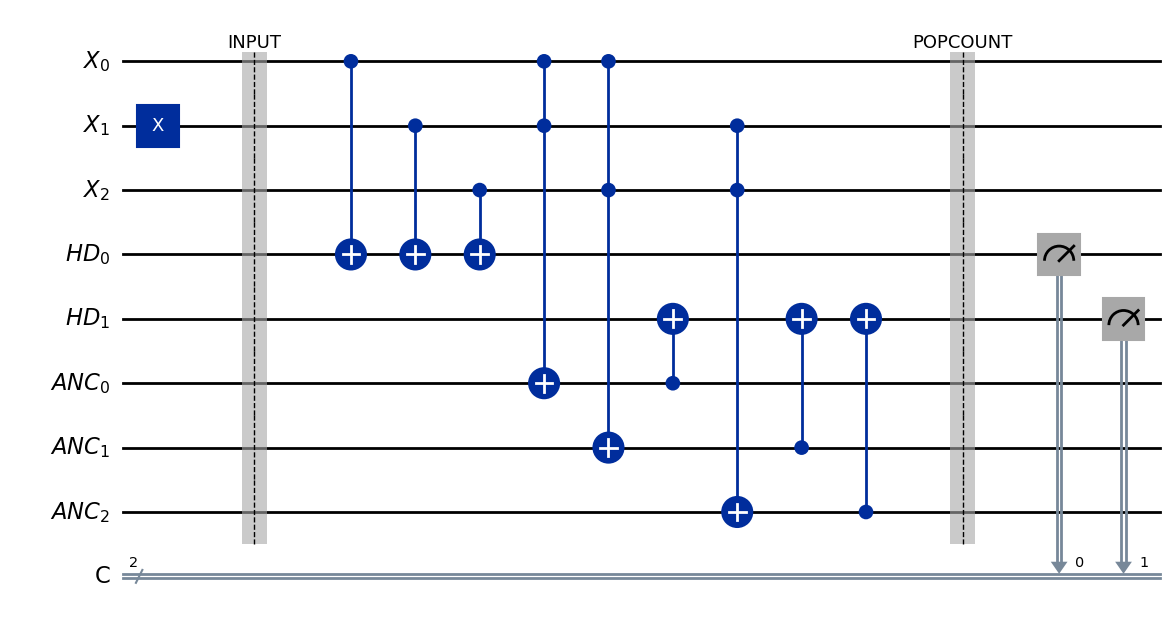

qiskit_runtime_service.__init__:WARNING:2026-07-11 21:58:31,476: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-11 21:58:31,478: Using instance: open-instance, plan: open



Backend : ibm_kingston

========== IBM HARDWARE METRICS ==========

Backend       : ibm_kingston
Circuit Depth : 109
Circuit Width : 158
Total Qubits  : 156
Circuit Size  : 204

Gate Counts:

OrderedDict([('sx', 89), ('rz', 67), ('cz', 44), ('x', 2), ('barrier', 2), ('measure', 2)])

IBM RUNTIME JOB SUBMITTED
Job ID : d996ud8tcv6s73dmu150

Waiting for execution...

Execution Complete.

Returned Data Structure:

DataBin(C=BitArray(<shape=(), num_shots=1024, num_bits=2>))

========== POPCOUNT RAW COUNTS ==========

{'01': 791, '00': 124, '11': 79, '10': 30}

========== SUCCESS PROBABILITY ==========

Success : 791/1024 = 77.25%

========== POPCOUNT HISTOGRAM ==========



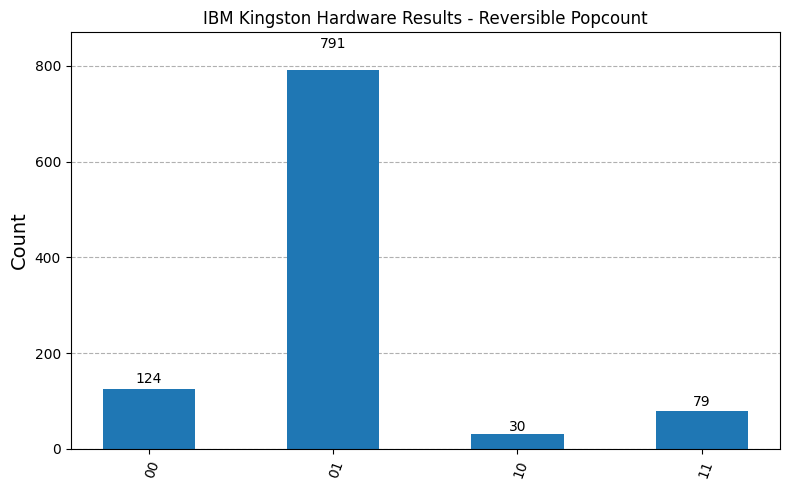


========== EXPECTED OUTPUT ==========

Input XOR Vector : 010
Hamming Weight   : 1
Expected HD      : 01

Execution completed successfully on IBM Kingston.


In [6]:
# ============================================================
# REVERSIBLE POPCOUNT BLOCK
# IBM KINGSTON HARDWARE EXECUTION
# ============================================================

from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    ClassicalRegister
)

from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

from qiskit.transpiler import generate_preset_pass_manager

from IPython.display import display

import matplotlib.pyplot as plt

# ============================================================
# REGISTERS
# ============================================================

# XOR Input

X = QuantumRegister(3, "X")

# Hamming Distance Output

HD = QuantumRegister(2, "HD")

# Ancilla

ANC = QuantumRegister(3, "ANC")

# Classical Register

C = ClassicalRegister(2, "C")

# ============================================================
# CIRCUIT
# ============================================================

qc = QuantumCircuit(
    X,
    HD,
    ANC,
    C
)

# ============================================================
# INPUT INITIALIZATION
#
# X = 010
# ============================================================

qc.x(X[1])

qc.barrier(label="INPUT")

# ============================================================
# REVERSIBLE POPCOUNT
# ============================================================

# ----------------------------
# HD[0] = PARITY
# ----------------------------

qc.cx(X[0], HD[0])
qc.cx(X[1], HD[0])
qc.cx(X[2], HD[0])

# ----------------------------
# HD[1] = MAJORITY
# ----------------------------

qc.ccx(X[0], X[1], ANC[0])
qc.ccx(X[0], X[2], ANC[1])
qc.ccx(X[1], X[2], ANC[2])

qc.cx(ANC[0], HD[1])
qc.cx(ANC[1], HD[1])
qc.cx(ANC[2], HD[1])

qc.barrier(label="POPCOUNT")

# ============================================================
# MEASUREMENTS
# ============================================================

qc.measure(HD, C)

# ============================================================
# DRAW CIRCUIT
# ============================================================

print("\n========== POPCOUNT CIRCUIT ==========\n")

fig = qc.draw(
    output="mpl",
    fold=120,
    idle_wires=False,
    style="iqp"
)

display(fig)

plt.show()

fig.savefig(
    "popcount_circuit.png",
    dpi=300,
    bbox_inches="tight"
)

# ============================================================
# IBM QUANTUM SERVICE
# ============================================================

service = QiskitRuntimeService()

backend = service.backend("ibm_kingston")

print("\n====================================================")
print("Backend :", backend.name)
print("====================================================")

# ============================================================
# HARDWARE-AWARE TRANSPILATION
# ============================================================

pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend
)

transpiled_qc = pm.run(qc)

# ============================================================
# IBM HARDWARE METRICS
# ============================================================

print("\n========== IBM HARDWARE METRICS ==========\n")

print("Backend       :", backend.name)
print("Circuit Depth :", transpiled_qc.depth())
print("Circuit Width :", transpiled_qc.width())
print("Total Qubits  :", backend.num_qubits)
print("Circuit Size  :", transpiled_qc.size())

print("\nGate Counts:\n")

print(transpiled_qc.count_ops())

# ============================================================
# IBM RUNTIME
# ============================================================

sampler = Sampler(mode=backend)

job = sampler.run(
    [transpiled_qc],
    shots=1024
)

print("\n====================================================")
print("IBM RUNTIME JOB SUBMITTED")
print("====================================================")

print("Job ID :", job.job_id())

print("\nWaiting for execution...\n")

result = job.result()

print("Execution Complete.")

# ============================================================
# DATA
# ============================================================

pub = result[0]

print("\nReturned Data Structure:\n")

print(pub.data)

counts = pub.data.C.get_counts()

# ============================================================
# COUNTS
# ============================================================

print("\n========== POPCOUNT RAW COUNTS ==========\n")

print(counts)

# ============================================================
# SUCCESS PROBABILITY
# ============================================================

expected = "01"

success = counts.get(expected, 0)

shots = sum(counts.values())

print("\n========== SUCCESS PROBABILITY ==========\n")

print(
    f"Success : {success}/{shots} = {100*success/shots:.2f}%"
)

# ============================================================
# HISTOGRAM
# ============================================================

print("\n========== POPCOUNT HISTOGRAM ==========\n")

hist = plot_histogram(
    counts,
    figsize=(8,5),
    title="IBM Kingston Hardware Results - Reversible Popcount"
)

display(hist)

hist.savefig(
    "ibm_popcount_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# EXPECTED OUTPUT
# ============================================================

print("\n========== EXPECTED OUTPUT ==========\n")

print("Input XOR Vector : 010")
print("Hamming Weight   : 1")
print("Expected HD      : 01")

print("\nExecution completed successfully on IBM Kingston.")

In [ ]:
comparator


========== COMPARATOR CIRCUIT ==========



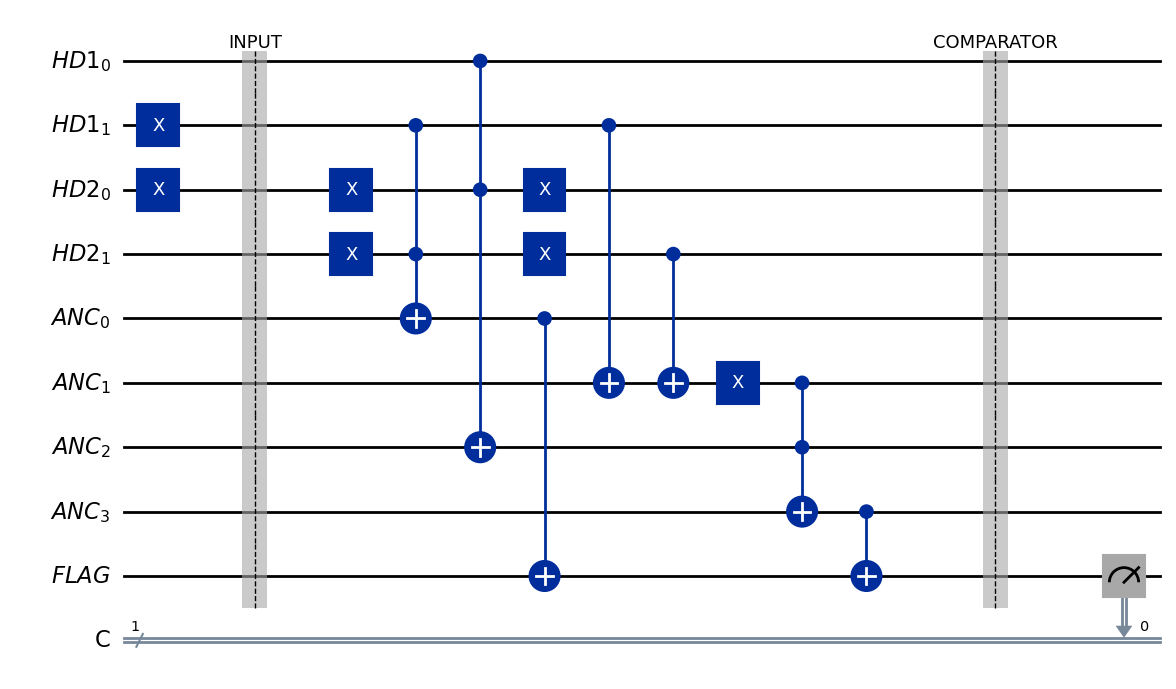

qiskit_runtime_service.__init__:WARNING:2026-07-11 22:51:59,929: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-11 22:51:59,939: Using instance: open-instance, plan: open



Backend : ibm_kingston

========== IBM HARDWARE METRICS ==========

Backend       : ibm_kingston
Circuit Depth : 75
Circuit Width : 157
Total Qubits  : 156
Circuit Size  : 165

Gate Counts:

OrderedDict([('sx', 67), ('rz', 59), ('cz', 34), ('x', 4), ('barrier', 2), ('measure', 1)])

IBM RUNTIME JOB SUBMITTED
Job ID : d997nfaf47jc73a8np80

Waiting for execution...



In [ ]:

# ============================================================
# REVERSIBLE COMPARATOR NETWORK
# IBM KINGSTON HARDWARE EXECUTION
# ============================================================

from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    ClassicalRegister
)

from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

from qiskit.transpiler import generate_preset_pass_manager

from IPython.display import display

import matplotlib.pyplot as plt

# ============================================================
# REGISTERS
# ============================================================

HD1 = QuantumRegister(2, "HD1")
HD2 = QuantumRegister(2, "HD2")
ANC = QuantumRegister(4, "ANC")
FLAG = QuantumRegister(1, "FLAG")

C = ClassicalRegister(1, "C")

# ============================================================
# CIRCUIT
# ============================================================

qc = QuantumCircuit(
    HD1,
    HD2,
    ANC,
    FLAG,
    C
)

# ============================================================
# INPUT
#
# HD1 = 10
# HD2 = 01
#
# FLAG should become 1
# ============================================================

qc.x(HD1[1])

qc.x(HD2[0])

qc.barrier(label="INPUT")

# ============================================================
# REVERSIBLE COMPARATOR
# ============================================================

# -------------------------
# Compare MSB
# -------------------------

qc.x(HD2[1])

qc.ccx(
    HD1[1],
    HD2[1],
    ANC[0]
)

qc.x(HD2[1])

# -------------------------
# Equality Check
# -------------------------

qc.cx(HD1[1], ANC[1])
qc.cx(HD2[1], ANC[1])

qc.x(ANC[1])

# -------------------------
# Compare LSB
# -------------------------

qc.x(HD2[0])

qc.ccx(
    HD1[0],
    HD2[0],
    ANC[2]
)

qc.x(HD2[0])

# -------------------------
# Final Combination
# -------------------------

qc.ccx(
    ANC[1],
    ANC[2],
    ANC[3]
)

qc.cx(ANC[0], FLAG[0])

qc.cx(ANC[3], FLAG[0])

qc.barrier(label="COMPARATOR")

# ============================================================
# MEASURE
# ============================================================

qc.measure(FLAG, C)

# ============================================================
# DRAW CIRCUIT
# ============================================================

print("\n========== COMPARATOR CIRCUIT ==========\n")

fig = qc.draw(
    output="mpl",
    fold=120,
    idle_wires=False,
    style="iqp"
)

display(fig)

plt.show()

fig.savefig(
    "comparator_circuit.png",
    dpi=300,
    bbox_inches="tight"
)

# ============================================================
# IBM QUANTUM
# ============================================================

service = QiskitRuntimeService()

backend = service.backend("ibm_kingston")

print("\n====================================================")
print("Backend :", backend.name)
print("====================================================")

# ============================================================
# HARDWARE-AWARE TRANSPILATION
# ============================================================

pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend
)

transpiled_qc = pm.run(qc)

# ============================================================
# HARDWARE METRICS
# ============================================================

print("\n========== IBM HARDWARE METRICS ==========\n")

print("Backend       :", backend.name)
print("Circuit Depth :", transpiled_qc.depth())
print("Circuit Width :", transpiled_qc.width())
print("Total Qubits  :", backend.num_qubits)
print("Circuit Size  :", transpiled_qc.size())

print("\nGate Counts:\n")

print(transpiled_qc.count_ops())

# ============================================================
# IBM RUNTIME
# ============================================================

sampler = Sampler(mode=backend)

job = sampler.run(
    [transpiled_qc],
    shots=1024
)

print("\n====================================================")
print("IBM RUNTIME JOB SUBMITTED")
print("====================================================")

print("Job ID :", job.job_id())

print("\nWaiting for execution...\n")

result = job.result()

print("Execution Complete.")

# ============================================================
# EXTRACT COUNTS
# ============================================================

pub = result[0]

print("\nReturned Data Structure:\n")

print(pub.data)

counts = pub.data.C.get_counts()

# ============================================================
# RAW COUNTS
# ============================================================

print("\n========== COMPARATOR RAW COUNTS ==========\n")

print(counts)

# ============================================================
# SUCCESS PROBABILITY
# ============================================================

expected = "1"

success = counts.get(expected, 0)

shots = sum(counts.values())

print("\n========== SUCCESS PROBABILITY ==========\n")

print(
    f"Success : {success}/{shots} = {100*success/shots:.2f}%"
)

# ============================================================
# HISTOGRAM
# ============================================================

print("\n========== COMPARATOR HISTOGRAM ==========\n")

hist = plot_histogram(
    counts,
    figsize=(8,5),
    title="IBM Kingston Hardware Results - Reversible Comparator"
)

display(hist)

hist.savefig(
    "ibm_comparator_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# EXPECTED OUTPUT
# ============================================================

print("\n========== EXPECTED OUTPUT ==========\n")

print("HD1 = 01 (decimal 1)")
print("HD2 = 10 (decimal 2)")
print("Expected FLAG = 1")

print("\nExecution completed successfully on IBM Kingston.")


In [8]:
fredkin selection

SyntaxError: invalid syntax (252272913.py, line 1)


========== FREDKIN ROUTING CIRCUIT ==========



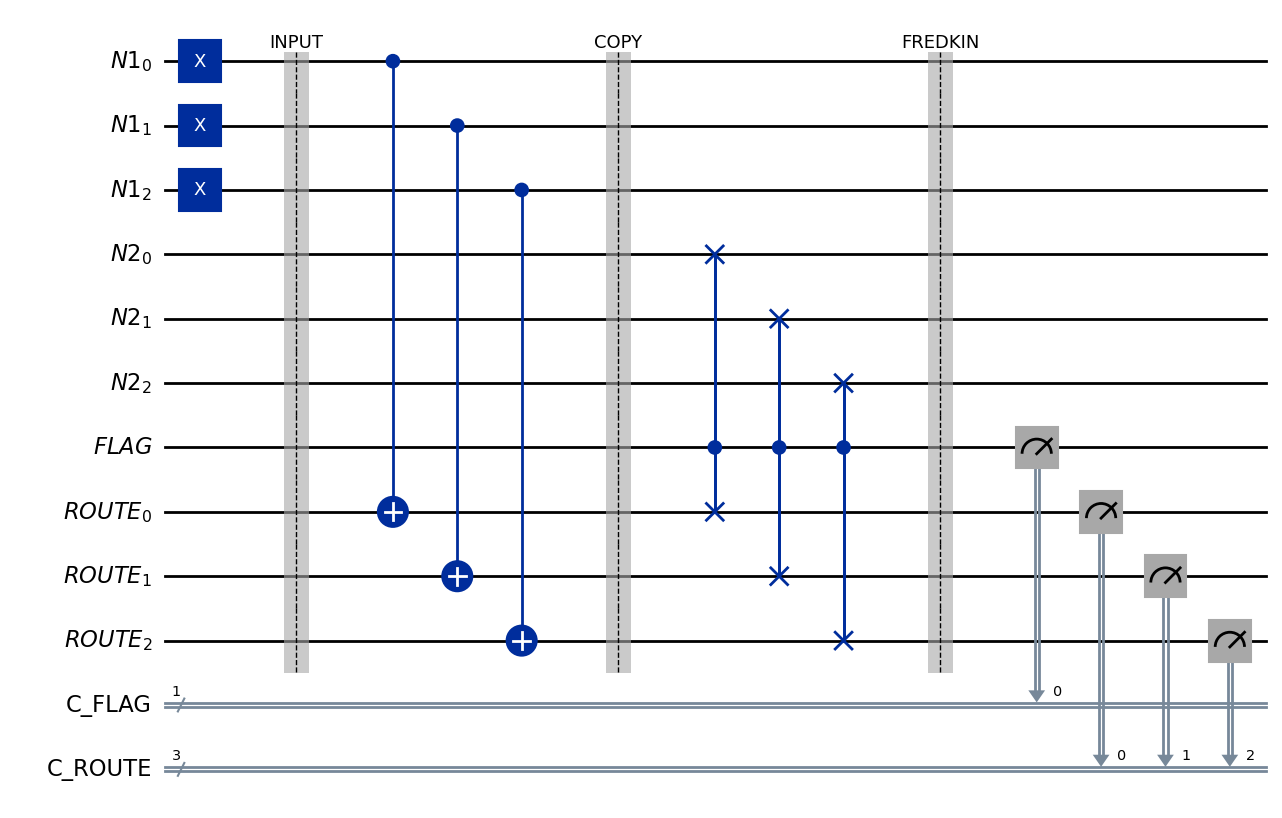

qiskit_runtime_service.__init__:WARNING:2026-07-12 09:01:02,468: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-12 09:01:02,468: Using instance: open-instance, plan: open



Backend : ibm_kingston

========== IBM HARDWARE METRICS ==========

Backend       : ibm_kingston
Circuit Depth : 94
Circuit Width : 160
Total Qubits  : 156
Circuit Size  : 144

Gate Counts:

OrderedDict([('sx', 57), ('rz', 46), ('cz', 33), ('x', 4), ('measure', 4), ('barrier', 3)])

IBM RUNTIME JOB SUBMITTED
Job ID : d99gkuotcv6s73dna010

Waiting for execution...

Execution Complete.

Returned Data Structure:

DataBin(C_FLAG=BitArray(<shape=(), num_shots=1024, num_bits=1>), C_ROUTE=BitArray(<shape=(), num_shots=1024, num_bits=3>))

========== FLAG RAW COUNTS ==========

{'0': 1010, '1': 14}

========== ROUTE RAW COUNTS ==========

{'101': 35, '111': 797, '110': 63, '011': 105, '100': 5, '000': 8, '001': 4, '010': 7}

========== SUCCESS PROBABILITY ==========

FLAG  : 1010/1024 = 98.63%
ROUTE : 797/1024 = 77.83%

========== FLAG HISTOGRAM ==========



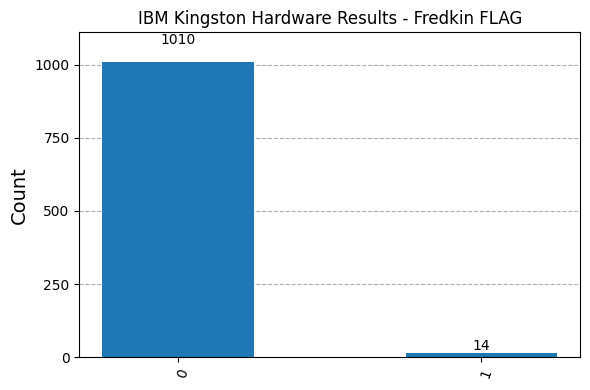


========== ROUTE HISTOGRAM ==========



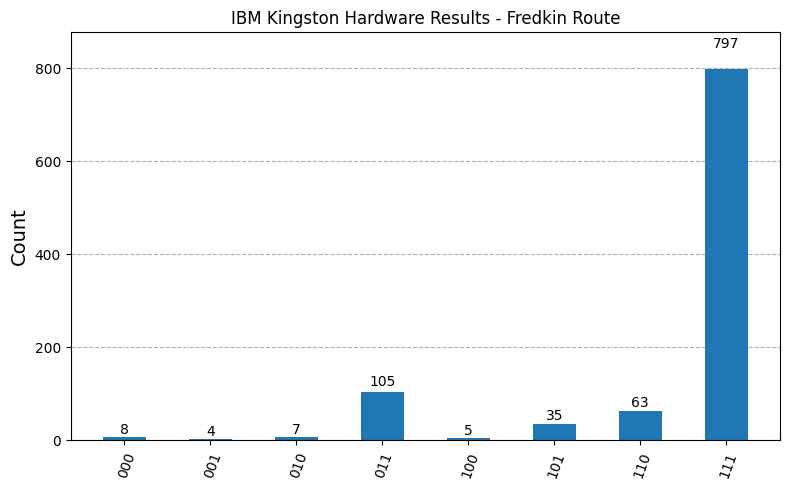


========== EXPECTED OUTPUT ==========

Destination : 101
Neighbor 1  : 111
Neighbor 2  : 000

Comparator FLAG : 0

Expected Route : 111


In [3]:

# ============================================================
# FREDKIN-BASED REVERSIBLE ROUTING
# IBM KINGSTON HARDWARE EXECUTION
# ============================================================

from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    ClassicalRegister
)

from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

from qiskit.transpiler import generate_preset_pass_manager

from IPython.display import display

import matplotlib.pyplot as plt

# ============================================================
# REGISTERS
# ============================================================

N1 = QuantumRegister(3,"N1")
N2 = QuantumRegister(3,"N2")
FLAG = QuantumRegister(1,"FLAG")
ROUTE = QuantumRegister(3,"ROUTE")

C_FLAG = ClassicalRegister(1,"C_FLAG")
C_ROUTE = ClassicalRegister(3,"C_ROUTE")

# ============================================================
# CIRCUIT
# ============================================================

qc = QuantumCircuit(
    N1,
    N2,
    FLAG,
    ROUTE,
    C_FLAG,
    C_ROUTE
)

# ============================================================
# INPUT
#
# D  = 101
# N1 = 111
# N2 = 000
#
# Comparator Output
#
# FLAG = 0
#
# Expected ROUTE = 111
# ============================================================

# FLAG = 0
# (No X gate on FLAG)

# N1 = 111

qc.x(N1[0])
qc.x(N1[1])
qc.x(N1[2])

# N2 = 000
# (No initialization required)

qc.barrier(label="INPUT")

# ============================================================
# INITIAL COPY
# ============================================================

for i in range(3):
    qc.cx(N1[i], ROUTE[i])

qc.barrier(label="COPY")

# ============================================================
# FREDKIN ROUTING
# ============================================================

for i in range(3):
    qc.cswap(
        FLAG[0],
        ROUTE[i],
        N2[i]
    )

qc.barrier(label="FREDKIN")

# ============================================================
# MEASUREMENTS
# ============================================================

qc.measure(FLAG,C_FLAG)

qc.measure(ROUTE,C_ROUTE)

# ============================================================
# DRAW CIRCUIT
# ============================================================

print("\n========== FREDKIN ROUTING CIRCUIT ==========\n")

fig = qc.draw(
    output="mpl",
    fold=120,
    idle_wires=False,
    style="iqp"
)

display(fig)

plt.show()

fig.savefig(
    "fredkin_routing_circuit.png",
    dpi=300,
    bbox_inches="tight"
)

# ============================================================
# IBM QUANTUM
# ============================================================

service = QiskitRuntimeService()

backend = service.backend("ibm_kingston")

print("\n====================================================")
print("Backend :", backend.name)
print("====================================================")

# ============================================================
# TRANSPILATION
# ============================================================

pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend
)

transpiled_qc = pm.run(qc)

# ============================================================
# HARDWARE METRICS
# ============================================================

print("\n========== IBM HARDWARE METRICS ==========\n")

print("Backend       :",backend.name)
print("Circuit Depth :",transpiled_qc.depth())
print("Circuit Width :",transpiled_qc.width())
print("Total Qubits  :",backend.num_qubits)
print("Circuit Size  :",transpiled_qc.size())

print("\nGate Counts:\n")

print(transpiled_qc.count_ops())

# ============================================================
# IBM RUNTIME
# ============================================================

sampler = Sampler(mode=backend)

job = sampler.run(
    [transpiled_qc],
    shots=1024
)

print("\n====================================================")
print("IBM RUNTIME JOB SUBMITTED")
print("====================================================")

print("Job ID :",job.job_id())

print("\nWaiting for execution...\n")

result = job.result()

print("Execution Complete.")

# ============================================================
# DATA
# ============================================================

pub = result[0]

print("\nReturned Data Structure:\n")

print(pub.data)

flag_counts = pub.data.C_FLAG.get_counts()

route_counts = pub.data.C_ROUTE.get_counts()

# ============================================================
# RAW COUNTS
# ============================================================

print("\n========== FLAG RAW COUNTS ==========\n")

print(flag_counts)

print("\n========== ROUTE RAW COUNTS ==========\n")

print(route_counts)

# ============================================================
# SUCCESS PROBABILITY
# ============================================================
expected_flag="0"

expected_route="111"

flag_success=flag_counts.get(expected_flag,0)

route_success=route_counts.get(expected_route,0)

flag_total=sum(flag_counts.values())

route_total=sum(route_counts.values())

print("\n========== SUCCESS PROBABILITY ==========\n")

print(
    f"FLAG  : {flag_success}/{flag_total} = {100*flag_success/flag_total:.2f}%"
)

print(
    f"ROUTE : {route_success}/{route_total} = {100*route_success/route_total:.2f}%"
)

# ============================================================
# FLAG HISTOGRAM
# ============================================================

print("\n========== FLAG HISTOGRAM ==========\n")

flag_fig=plot_histogram(
    flag_counts,
    figsize=(6,4),
    title="IBM Kingston Hardware Results - Fredkin FLAG"
)

display(flag_fig)

flag_fig.savefig(
    "ibm_fredkin_flag_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# ROUTE HISTOGRAM
# ============================================================

print("\n========== ROUTE HISTOGRAM ==========\n")

route_fig=plot_histogram(
    route_counts,
    figsize=(8,5),
    title="IBM Kingston Hardware Results - Fredkin Route"
)

display(route_fig)

route_fig.savefig(
    "ibm_fredkin_route_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# EXPECTED OUTPUT
# ============================================================

print("\n========== EXPECTED OUTPUT ==========\n")
print("Destination : 101")
print("Neighbor 1  : 111")
print("Neighbor 2  : 000")

print()

print("Comparator FLAG : 0")

print()

print("Expected Route : 111")

In [10]:
# IBM Kingston 512-case batch validation scaffold
from itertools import product
import csv
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager

SHOTS=256
BATCH_SIZE=64

# Paste your existing initialize_bits(), router(), and hamming() functions ABOVE this section.
# =========================
# HELPER
# =========================
def initialize_bits(qc, reg, bitstring):
    for i, b in enumerate(reversed(bitstring)):
        if b == '1':
            qc.x(reg[i])


# =========================
# ROUTER (FULL REVERSIBLE)
# =========================
def router(D_val, N1_val, N2_val):

    D  = QuantumRegister(3, 'D')
    N1 = QuantumRegister(3, 'N1')
    N2 = QuantumRegister(3, 'N2')

    X1 = QuantumRegister(3, 'X1')
    X2 = QuantumRegister(3, 'X2')

    d1 = QuantumRegister(2, 'd1')
    d2 = QuantumRegister(2, 'd2')

    anc = QuantumRegister(9, 'anc')
    flag = QuantumRegister(1, 'flag')

    OUT = QuantumRegister(3, 'OUT')
    c = ClassicalRegister(3, 'c')

    qc = QuantumCircuit(D, N1, N2, X1, X2, d1, d2, anc, flag, OUT, c)

    # INPUT
    initialize_bits(qc, D, D_val)
    initialize_bits(qc, N1, N1_val)
    initialize_bits(qc, N2, N2_val)

    # XOR
    for i in range(3):
        qc.cx(N1[i], X1[i])
        qc.cx(D[i],  X1[i])

        qc.cx(N2[i], X2[i])
        qc.cx(D[i],  X2[i])

    # POPCOUNT d1
    qc.cx(X1[0], d1[0])
    qc.cx(X1[1], d1[0])
    qc.cx(X1[2], d1[0])

    qc.ccx(X1[0], X1[1], anc[0])
    qc.ccx(X1[0], X1[2], anc[1])
    qc.ccx(X1[1], X1[2], anc[2])

    qc.cx(anc[0], d1[1])
    qc.cx(anc[1], d1[1])
    qc.cx(anc[2], d1[1])

    # POPCOUNT d2
    qc.cx(X2[0], d2[0])
    qc.cx(X2[1], d2[0])
    qc.cx(X2[2], d2[0])

    qc.ccx(X2[0], X2[1], anc[3])
    qc.ccx(X2[0], X2[2], anc[4])
    qc.ccx(X2[1], X2[2], anc[5])

    qc.cx(anc[3], d2[1])
    qc.cx(anc[4], d2[1])
    qc.cx(anc[5], d2[1])

    # =========================
    # COMPARATOR (d1 > d2)
    # =========================
    qc.x(d2[1])
    qc.ccx(d1[1], d2[1], flag[0])
    qc.x(d2[1])

    qc.cx(d1[1], anc[6])
    qc.cx(d2[1], anc[6])
    qc.x(anc[6])

    qc.x(d2[0])
    qc.ccx(d1[0], d2[0], anc[7])
    qc.x(d2[0])

    qc.ccx(anc[6], anc[7], anc[8])
    qc.cx(anc[8], flag[0])

    # =========================
    # SELECTION
    # =========================
    for i in range(3):
        qc.ccx(flag[0], N2[i], OUT[i])
        qc.x(flag[0])
        qc.ccx(flag[0], N1[i], OUT[i])
        qc.x(flag[0])

    # =========================
    # UNCOMPUTE
    # =========================

    qc.cx(anc[8], flag[0])
    qc.ccx(anc[6], anc[7], anc[8])

    qc.x(d2[0])
    qc.ccx(d1[0], d2[0], anc[7])
    qc.x(d2[0])

    qc.x(anc[6])
    qc.cx(d2[1], anc[6])
    qc.cx(d1[1], anc[6])

    qc.x(d2[1])
    qc.ccx(d1[1], d2[1], flag[0])
    qc.x(d2[1])

    qc.cx(anc[5], d2[1])
    qc.cx(anc[4], d2[1])
    qc.cx(anc[3], d2[1])

    qc.ccx(X2[1], X2[2], anc[5])
    qc.ccx(X2[0], X2[2], anc[4])
    qc.ccx(X2[0], X2[1], anc[3])

    qc.cx(X2[2], d2[0])
    qc.cx(X2[1], d2[0])
    qc.cx(X2[0], d2[0])

    qc.cx(anc[2], d1[1])
    qc.cx(anc[1], d1[1])
    qc.cx(anc[0], d1[1])

    qc.ccx(X1[1], X1[2], anc[2])
    qc.ccx(X1[0], X1[2], anc[1])
    qc.ccx(X1[0], X1[1], anc[0])

    qc.cx(X1[2], d1[0])
    qc.cx(X1[1], d1[0])
    qc.cx(X1[0], d1[0])

    for i in range(3):
        qc.cx(D[i],  X2[i])
        qc.cx(N2[i], X2[i])

        qc.cx(D[i],  X1[i])
        qc.cx(N1[i], X1[i])

    # MEASURE
    for i in range(3):
        qc.measure(OUT[i], c[i])

    return qc


# =========================
# TEST FUNCTIONS
# =========================
def hamming(a, b):
    return sum(x != y for x, y in zip(a, b))


def run_test(D, N1, N2):

    qc = router(D, N1, N2)

    backend = Aer.get_backend('aer_simulator')
    backend.set_options(method="matrix_product_state")

    result = backend.run(qc, shots=1).result()
    measured = list(result.get_counts().keys())[0]

    d1 = hamming(D, N1)
    d2 = hamming(D, N2)

    expected = N2 if d1 > d2 else N1

    print("====================================")
    print(f"D={D}  N1={N1}  N2={N2}")
    print(f"Expected: {expected}")
    print(f"Measured: {measured}")

    if measured == expected:
        print("✔ PASS")
    else:
        print("❌ FAIL")
def chunks(lst,n):
    for i in range(0,len(lst),n):
        yield lst[i:i+n]

def build_all_cases():
    circuits=[]; expected=[]; metadata=[]
    for D in product("01", repeat=3):
        for N1 in product("01", repeat=3):
            for N2 in product("01", repeat=3):
                D="".join(D); N1="".join(N1); N2="".join(N2)
                qc=router(D,N1,N2)
                d1=hamming(D,N1); d2=hamming(D,N2)
                exp=N2 if d1>d2 else N1
                circuits.append(qc); expected.append(exp); metadata.append((D,N1,N2))
    return circuits,expected,metadata

def run_all_512_ibm():
    circuits,expected,metadata=build_all_cases()
    service=QiskitRuntimeService()
    backend=service.backend("ibm_kingston")
    pm=generate_preset_pass_manager(optimization_level=3, backend=backend)
    rows=[]; passed=0; total=0
    for b,batch in enumerate(chunks(list(range(len(circuits))),BATCH_SIZE),1):
        print(f"Batch {b}")
        trans=pm.run([circuits[i] for i in batch])
        sampler=Sampler(mode=backend)
        job=sampler.run(trans, shots=SHOTS)
        print("Job:",job.job_id())
        res=job.result()
        for li,gi in enumerate(batch):
            counts=res[li].data.c.get_counts()  # adjust if register name differs
            dom=max(counts,key=counts.get)
            prob=counts[dom]/SHOTS
            ok=(dom==expected[gi])
            if ok: passed+=1
            total+=1
            D,N1,N2=metadata[gi]
            rows.append([gi+1,D,N1,N2,expected[gi],dom,prob,"PASS" if ok else "FAIL"])
    with open("ibm_kingston_512_results.csv","w",newline="") as f:
        w=csv.writer(f)
        w.writerow(["Case","D","N1","N2","Expected","Dominant","Probability","Status"])
        w.writerows(rows)
    print("Total",total,"Passed",passed,"Accuracy",100*passed/total)

if __name__=="__main__":
    run_all_512_ibm()


qiskit_runtime_service.__init__:WARNING:2026-07-11 22:04:09,753: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-11 22:04:09,753: Using instance: open-instance, plan: open


Batch 1
Job: d9971asqp3as739to7i0
Batch 2
Job: d9971rqf47jc73a8mv2g
Batch 3
Job: d9972g52su3c739k2jr0
Batch 4
Job: d99732qf47jc73a8n0g0
Batch 5
Job: d9973lgtcv6s73dmu750
Batch 6
Job: d99745if47jc73a8n1og
Batch 7
Job: d9974m0tcv6s73dmu8dg
Batch 8
Job: d99756d2su3c739k2mq0
Total 512 Passed 426 Accuracy 83.203125


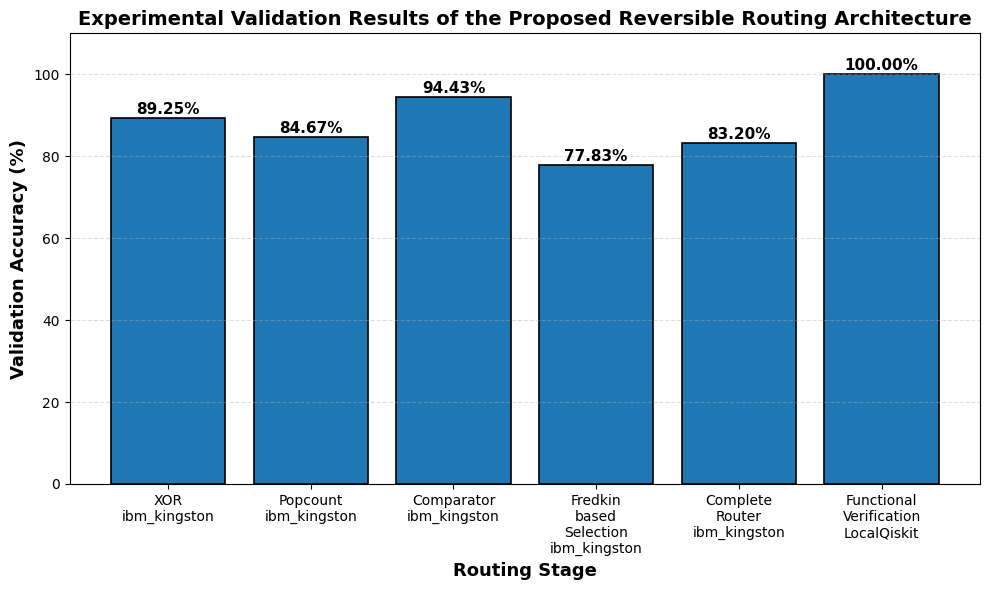

In [8]:
import matplotlib.pyplot as plt

# ===============================
# Experimental Validation Results
# ===============================

stages = [
    "XOR\nibm_kingston",
    "Popcount\nibm_kingston",
    "Comparator\nibm_kingston",
    "Fredkin\nbased\nSelection\nibm_kingston",
    "Complete\nRouter\nibm_kingston",
    "Functional\nVerification\nLocalQiskit"
]

accuracy = [89.25, 84.67, 94.43, 77.83, 83.20, 100.00]

# ===============================
# Plot
# ===============================

plt.figure(figsize=(10,6))

bars = plt.bar(
    stages,
    accuracy,
    edgecolor='black',
    linewidth=1.2
)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}%",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0,110)

plt.ylabel("Validation Accuracy (%)", fontsize=13, fontweight='bold')
plt.xlabel("Routing Stage", fontsize=13, fontweight='bold')

plt.title(
    "Experimental Validation Results of the Proposed Reversible Routing Architecture",
    fontsize=14,
    fontweight='bold'
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig("Experimental_Validation_BarGraph.png", dpi=600)

plt.show()